# EDA T-ECD
Анализ выполняется на фактически скачанных дневных партициях. Это не статистика полного T-ECD.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tecd_pipeline import load_events, find_dataset_root
from tecd_downloader import download_dataset

import os
import time
import json
import logging
from datetime import datetime


DATA_DIR = "data/t_ecd"


c:\Users\Admin\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
log = logging.getLogger("dataset_pipeline")


In [3]:
hf_token = os.getenv("HF_TOKEN")


In [4]:
# ── Параметры ──────────────────────────────────────────────────────
LOCAL_DIR    = "data/t_ecd"
DATASET_PATH = "dataset/small"
DOMAINS     = ["retail", "marketplace", "offers"]
DAY_BEGIN   = 1250
DAY_END     = 1308
MAX_WORKERS = 10

CHUNK_SIZE      = 7      # сколько дней качать за один заход
INITIAL_DELAY  = 5      # пауза между чанками (сек)
RATE_LIMIT_WAIT = 60    # ждать (сек) при срабатывании лимита
MAX_RETRIES    = 5     # максимум попыток на один чанк
BACKOFF_FACTOR = 2      # множитель для экспоненциального ожидания

PROGRESS_FILE = os.path.join(LOCAL_DIR, "_progress.json")


In [5]:
# ── Чанки ───────────────────────────────────────────────────────────
def build_chunks(begin, end, size):
    """Разбивает [begin, end] на отрезки по `size` дней."""
    chunks = []
    cur = begin
    while cur <= end:
        stop = min(cur + size - 1, end)
        chunks.append((cur, stop))
        cur = stop + 1
    return chunks

In [6]:
# ── Прогресс ────────────────────────────────────────────────────────
def load_progress():
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE, "r") as f:
            return json.load(f)
    return {"done": [], "failed": []}

def save_progress(progress):
    os.makedirs(os.path.dirname(PROGRESS_FILE), exist_ok=True)
    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f, indent=2)

In [7]:
# ── Скачивание одного чанка с ретраями ──────────────────────────────
def download_chunk(day_start, day_end):
    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            download_dataset(
                token=hf_token,
                dataset_path=DATASET_PATH,
                local_dir=LOCAL_DIR,
                domains=DOMAINS,
                day_begin=day_start,
                day_end=day_end,
                max_workers=MAX_WORKERS,
            )
            log.info(f"Чанк {day_start}-{day_end} скачан успешно (попытка {attempt})")
            return True, None

        except RateLimitError as e:
            wait = RATE_LIMIT_WAIT * (BACKOFF_FACTOR ** (attempt - 1))
            log.warning(
                f"Rate limit на чанке {day_start}-{day_end}, "
                f"попытка {attempt}/{MAX_RETRIES}, жду {wait}с"
            )
            last_err = e
            time.sleep(wait)

        except Exception as e:
            wait = INITIAL_DELAY * (BACKOFF_FACTOR ** (attempt - 1))
            log.error(
                f"Ошибка чанка {day_start}-{day_end}, "
                f"попытка {attempt}/{MAX_RETRIES}: {e}"
            )
            last_err = e
            time.sleep(wait)

    return False, str(last_err)


In [8]:
def run_pipeline():
    chunks = build_chunks(DAY_BEGIN, DAY_END, CHUNK_SIZE)
    progress = load_progress()
    done_set = set(map(tuple, progress["done"]))

    pending = [c for c in chunks if tuple(c) not in done_set]
    log.info(
        f"Всего чанков: {len(chunks)}, уже скачано: {len(done_set)}, "
        f"осталось: {len(pending)}"
    )

    for i, (start, end) in enumerate(pending, 1):
        log.info(f"→ [{i}/{len(pending)}] Чанк {start}-{end}")

        ok, err = download_chunk(start, end)
        if ok:
            progress["done"].append([start, end])
            save_progress(progress)
        else:
            progress["failed"].append({"chunk": [start, end], "error": err})
            save_progress(progress)
            log.error(f"Чанк {start}-{end} провален после {MAX_RETRIES} попыток")

        # пауза между чанками
        if i < len(pending):
            time.sleep(INITIAL_DELAY)

    # итог
    if progress["failed"]:
        log.warning(f"Завершено с ошибками. Провалено чанков: {len(progress['failed'])}")
        log.warning("См. _progress.json в local_dir для деталей.")
    else:
        log.info("Все чанки скачаны успешно!")

In [9]:
run_pipeline()

2026-09-07 14:28:08,971 [INFO] Всего чанков: 9, уже скачано: 2, осталось: 7
2026-09-07 14:28:08,972 [INFO] → [1/7] Чанк 1264-1270


Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9fca-07886cee09381e8c44612cd1;3c70e57a-5a14-48ae-ada3-bd4728e91fc6)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 146 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main.
We had to rate limit your IP (95.25.208.236). To continue using our service, create a HF account or login to your existing account, and make sure you pass a HF_TOKEN if you're using the API.).
2026-09-07 14:28:09,228 [WARNING] Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9fca-07886cee09381e8c44612cd1;3c70e57a-5a14-48ae-ada3-bd4728e91fc6)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 146 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t

Download completed: 26/26 files successful


2026-09-07 14:28:14,688 [INFO] → [2/7] Чанк 1271-1277


Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9fcf-3d9fc2017a2587a07f31a4b8;58b14873-d8e7-44fe-9cca-2d53d55fd0db)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 141 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main.
We had to rate limit your IP (95.25.208.236). To continue using our service, create a HF account or login to your existing account, and make sure you pass a HF_TOKEN if you're using the API.).
2026-09-07 14:28:14,914 [WARNING] Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9fcf-3d9fc2017a2587a07f31a4b8;58b14873-d8e7-44fe-9cca-2d53d55fd0db)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 141 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t

...

2026-09-07 14:28:37,423 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main "HTTP/1.1 429 Too Many Requests"
Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9fe6-55e2a88337e25c0863d7ba33;0883b5d8-d5ab-47c5-872c-630f01b7aa19)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 118 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main.
We had to rate limit your IP (95.25.208.236). To continue using our service, create a HF account or login to your existing account, and make sure you pass a HF_TOKEN if you're using the API.).
2026-09-07 14:28:37,425 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main "HTTP/1.1 429 Too Many Requests"
2026-09-07 14:28:37,426 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main "HTTP

Download completed: 26/26 files successful


2026-09-07 14:28:42,820 [INFO] → [7/7] Чанк 1306-1308


Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9feb-0a34867c0875f3ab265c0fa3;b96b7abd-c23d-49d8-b644-7e8cebe6b58b)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 113 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t-tech/T-ECD/revision/main.
We had to rate limit your IP (95.25.208.236). To continue using our service, create a HF account or login to your existing account, and make sure you pass a HF_TOKEN if you're using the API.).
2026-09-07 14:28:42,992 [WARNING] Returning existing local_dir `data\t_ecd` as remote repo cannot be accessed in `snapshot_download` ((Request ID: Root=1-6a9e9feb-0a34867c0875f3ab265c0fa3;b96b7abd-c23d-49d8-b644-7e8cebe6b58b)

429 Too Many Requests: you have reached your 'api' rate limit.
Retry after 113 seconds (0/500 requests remaining in current 300s window).
Url: https://huggingface.co/api/datasets/t

Download completed: 14/14 files successful


In [10]:
events = load_events(DATA_DIR, max_rows=2_000_000)
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      uint64
 1   item_id      object
 2   action_type  object
 3   subdomain    object
 4   os           object
 5   domain       object
 6   day          int64 
dtypes: int64(1), object(5), uint64(1)
memory usage: 106.8+ MB


In [11]:
display(events.head())
display(events.isna().mean().sort_values(ascending=False).to_frame("missing_share"))
display(events.nunique().sort_values().to_frame("unique"))

,user_id,item_id,action_type,subdomain,os,domain,day
0,10245230,nfmcg_8797298,view,u2i,ios,marketplace,1250
1,72946563,nfmcg_25817528,view,search,android,marketplace,1250
2,26314268,nfmcg_6136132,view,u2i,android,marketplace,1250
3,51262596,nfmcg_28303211,view,u2i,ios,marketplace,1250
4,16639898,nfmcg_1887189,view,catalog,other,marketplace,1250


,missing_share
subdomain,0.663829
os,0.663732
user_id,0.000000
action_type,0.000000
item_id,0.000000
domain,0.000000
day,0.000000


,unique
day,1
domain,2
os,3
action_type,4
subdomain,5
item_id,72371
user_id,189593


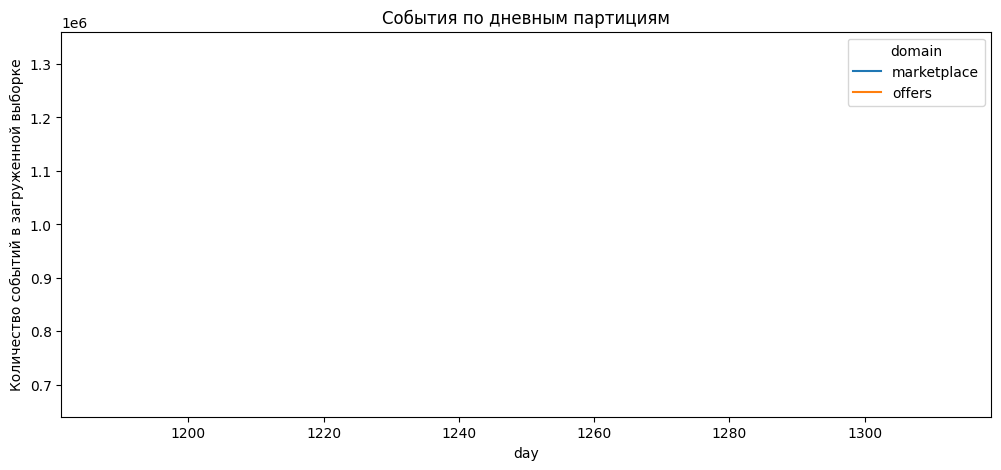

In [12]:
events.groupby(["day", "domain"]).size().unstack(fill_value=0).plot(figsize=(12, 5), title="События по дневным партициям")
plt.ylabel("Количество событий в загруженной выборке"); plt.show()

In [13]:
if "action_type" in events:
    display(events.groupby(["domain", "action_type"]).size().sort_values(ascending=False).head(30).to_frame("events"))

display(events.groupby("domain").agg(events=("user_id", "size"), users=("user_id", "nunique"), items=("item_id", "nunique")))

,,events
domain,action_type,
offers,view,1284069
marketplace,view,652666
offers,click,35626
marketplace,click,17453
offers,clickout,7007
marketplace,clickout,2222
offers,like,763
marketplace,like,194


,events,users,items
domain,,,
marketplace,672535,78635,71533
offers,1327465,131036,838


## Выводы
T-ECD — разреженный, временной и кросс-доменный implicit-feedback набор. Единые `user_id` и `brand_id` позволяют сопоставлять домены, но `item_id` следует интерпретировать вместе с доменом. Частоты действий и объектов несбалансированы, поэтому обучение ограничивается последовательным временным окном, а проверка проводится на последних днях. Численные выводы необходимо формулировать по таблицам выше для выбранного диапазона, не экстраполируя их на полный набор.